# Kaggle House Prices Prediction Model: Main Notebook
This notebook conforms to the "House Prices - Advanced Regression" challenge on Kaggle ([link here](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)). Here, you can find all the code for loading the data, setting up the model, and the various experimentations and attempts I've made to train a functional model.

The notebook is divided into sections based on the stage of model construction. Some code cells are based loosely off of various tutorials from Kaggle as a foundation.

*Competition goal*: It is your job to predict the sales price for each house. For each Id in the test set, you must predict the value of the SalePrice variable. Submissions are evaluated on Root-Mean-Squared-Error (RMSE) between the logarithm of the predicted value and the logarithm of the observed sales price.

## Load the data and import libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn.model_selection import train_test_split
import xgboost as xgb # in case we decide to build an XGBoost model (recommended)

# load the dataset from the CSV file
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()
test.head()

# verify the shapes of the datasets before modification
print("Train shape: {}".format(train.shape)) # should be (1460, 81)
print("Test shape: {}".format(test.shape)) # should be (1459, 80)

# save the ID column
train_ID = train['Id']
test_ID = test['Id']

# drop the ID column as it's unnecessary for the training process
train.drop("Id", axis=1, inplace=True)
test.drop("Id", axis=1, inplace=True)

# verify the shapes of the datasets after dropping the ID column
print("Train shape after dropping ID feature: {}" .format(train.shape)) # should be (1460, 80)
print("Test shape after dropping ID feature: {}" .format(test.shape)) # should be (1459, 79)

Train shape: (1460, 81)
Test shape: (1459, 80)
Train shape after dropping ID feature: (1460, 80)
Test shape after dropping ID feature: (1459, 79)


## Plot and analyze the data

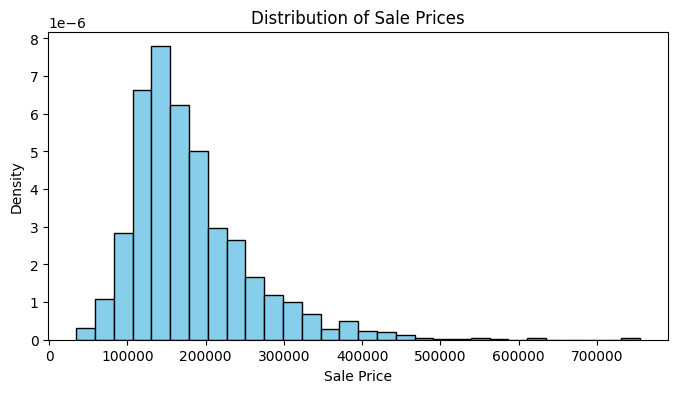

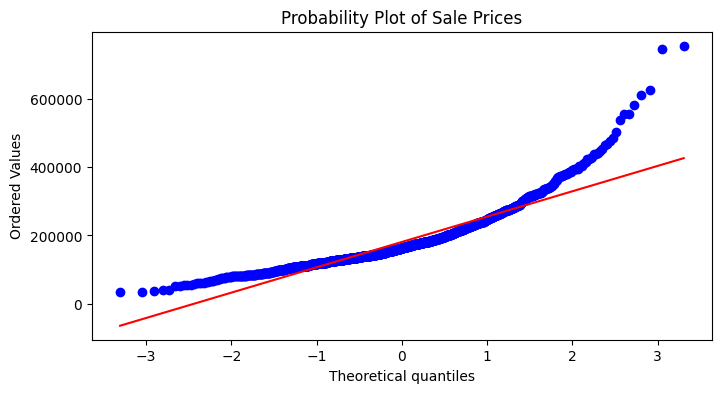

Skewness: 1.882876
Kurtosis: 6.536282


In [ ]:
# get a description of the sale prices
from scipy import stats

train['SalePrice'].describe()

# create a distribution plot of the sale prices
plt.figure(figsize=(8, 4))
plt.hist(train['SalePrice'], bins=30, density=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price')
plt.ylabel('Density')
plt.show()

# create a probability plot of the sale prices
plt.figure(figsize=(8, 4))
stats.probplot(train['SalePrice'], dist="norm", plot=plt)
plt.title("Probability Plot of Sale Prices")
plt.show()

# get the skewness and kurtosis of the sale prices
print("Skewness: %f" % train['SalePrice'].skew())
print("Kurtosis: %f" % train['SalePrice'].kurt())

# for this dataset, the skewness value is slightly above the normal, which means our data
# is a little bit skewed to the right in terms of tail length. The kurtosis is also above the normal,
# which indicates a higher possibility of extreme outliers.